#  Credit Risk — Loan Default Prediction & Threshold Optimization
### Home Credit Default Risk Dataset

**Objective:** Predict the likelihood of loan default and optimize the decision threshold using cost-benefit analysis to minimize total business cost.

---
**Pipeline Overview:**
1. Install & Import Libraries
2. Load & Explore the Dataset
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train / Test Split + Class Imbalance Handling
7. Model 1 — Logistic Regression
8. Model 2 — CatBoost
9. ROC-AUC & Precision-Recall Analysis
10. Business Cost-Benefit Analysis
11. Threshold Optimization to Minimize Total Cost
12. Final Model Comparison & Summary

##  Step 1: Install Required Libraries

In [1]:
!pip install catboost imbalanced-learn --quiet
print(' Libraries installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.8 MB/s eta 0:00:00
 Libraries installed!


##  Step 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# Imbalance
from imblearn.over_sampling import SMOTE

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

COLORS = {
    'primary'  : '#2c3e50',
    'danger'   : '#e74c3c',
    'success'  : '#2ecc71',
    'info'     : '#3498db',
    'warning'  : '#f39c12',
    'purple'   : '#9b59b6',
}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(' All libraries imported!')

 All libraries imported!


##  Step 3: Load & Explore the Dataset

> **If running in Google Colab**, uncomment and run the upload cell first.  
> **If running locally**, make sure `credit_risk_dataset.csv` is in the same directory.

In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('/content/credit_risk_dataset.csv.zip')

print(f' Dataset loaded!')
print(f'   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
df.head()

 Dataset loaded!
   Shape : 32,581 rows × 12 columns

Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

=== Descr

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== Missing Values ===')
print(missing_df)

# ── Target distribution ───────────────────────────────────────────────────────
print('\n=== Target Distribution (loan_status) ===')
vc = df['loan_status'].value_counts()
print(vc)
print(f'\n  Default rate : {vc[1]/len(df)*100:.2f}%')

=== Missing Values ===
                   Missing Count  Missing %
person_emp_length            895       2.75
loan_int_rate               3116       9.56

=== Target Distribution (loan_status) ===
loan_status
0    25473
1     7108
Name: count, dtype: int64

  Default rate : 21.82%


##  Step 4: Data Cleaning & Preprocessing

In [6]:
df_clean = df.copy()

# ── 1. Remove obvious outliers ────────────────────────────────────────────────
# Age > 100 is likely a data entry error
before = len(df_clean)
df_clean = df_clean[df_clean['person_age'] <= 100]
print(f'Removed {before - len(df_clean)} rows with age > 100')

# Income > 3M (extreme outliers — keep 99.9th percentile)
income_cap = df_clean['person_income'].quantile(0.999)
before = len(df_clean)
df_clean = df_clean[df_clean['person_income'] <= income_cap]
print(f'Removed {before - len(df_clean)} rows with income > {income_cap:,.0f}')

# Employment length > 60 years is likely an error
before = len(df_clean)
df_clean = df_clean[df_clean['person_emp_length'].isna() | (df_clean['person_emp_length'] <= 60)]
print(f'Removed {before - len(df_clean)} rows with emp_length > 60')

print(f'\n After cleaning: {len(df_clean):,} rows')

Removed 5 rows with age > 100
Removed 33 rows with income > 641,100
Removed 2 rows with emp_length > 60

 After cleaning: 32,541 rows


In [7]:
# ── 2. Handle missing values ──────────────────────────────────────────────────

# person_emp_length — fill with median (numeric, reasonable)
emp_median = df_clean['person_emp_length'].median()
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(emp_median)
print(f'person_emp_length: filled {df["person_emp_length"].isna().sum()} NaN with median ({emp_median})')

# loan_int_rate — fill with median per loan_grade (more accurate than global median)
grade_rate_median = df_clean.groupby('loan_grade')['loan_int_rate'].transform('median')
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(grade_rate_median)
print(f'loan_int_rate     : filled {df["loan_int_rate"].isna().sum()} NaN with grade-wise median')

print(f'\nRemaining missing values: {df_clean.isnull().sum().sum()}')

person_emp_length: filled 895 NaN with median (4.0)
loan_int_rate     : filled 3116 NaN with grade-wise median

Remaining missing values: 0


In [8]:
# ── 3. Encode categorical features ───────────────────────────────────────────

# Ordinal: loan_grade (A=best, G=worst)
grade_order = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_clean['loan_grade_enc'] = df_clean['loan_grade'].map(grade_order)

# Binary: cb_person_default_on_file
df_clean['cb_default_enc'] = (df_clean['cb_person_default_on_file'] == 'Y').astype(int)

# Nominal: one-hot encode (person_home_ownership, loan_intent)
df_clean = pd.get_dummies(df_clean,
                           columns=['person_home_ownership', 'loan_intent'],
                           drop_first=True)

# Drop original categorical columns now replaced
df_clean.drop(columns=['loan_grade', 'cb_person_default_on_file'], inplace=True)

# Convert bool columns to int
bool_cols = df_clean.select_dtypes(include='bool').columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(' Encoding complete!')
print(f'   Shape: {df_clean.shape}')
print(f'   Columns: {list(df_clean.columns)}')

 Encoding complete!
   Shape: (32541, 18)
   Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_grade_enc', 'cb_default_enc', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']


##  Step 5: Exploratory Data Analysis (EDA)

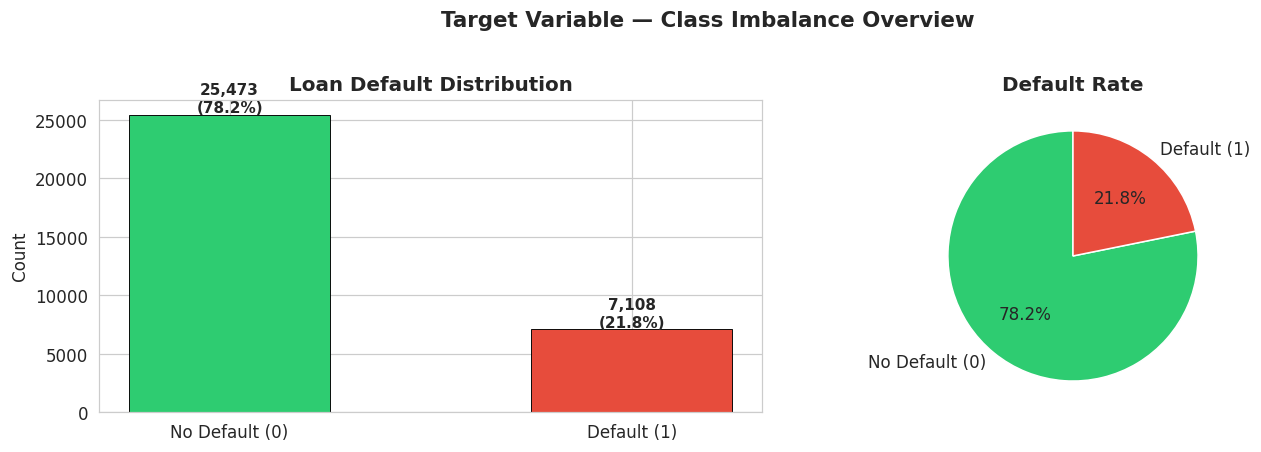

Class ratio (Default:No Default) = 1:3.6


In [9]:
# ── Target class distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

vc = df['loan_status'].value_counts()
labels = ['No Default (0)', 'Default (1)']
colors_pie = [COLORS['success'], COLORS['danger']]

axes[0].bar(labels, vc.values, color=colors_pie, edgecolor='black', linewidth=0.6, width=0.5)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Loan Default Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(vc.values, labels=labels, colors=colors_pie, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Default Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable — Class Imbalance Overview',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'Class ratio (Default:No Default) = 1:{vc[0]/vc[1]:.1f}')

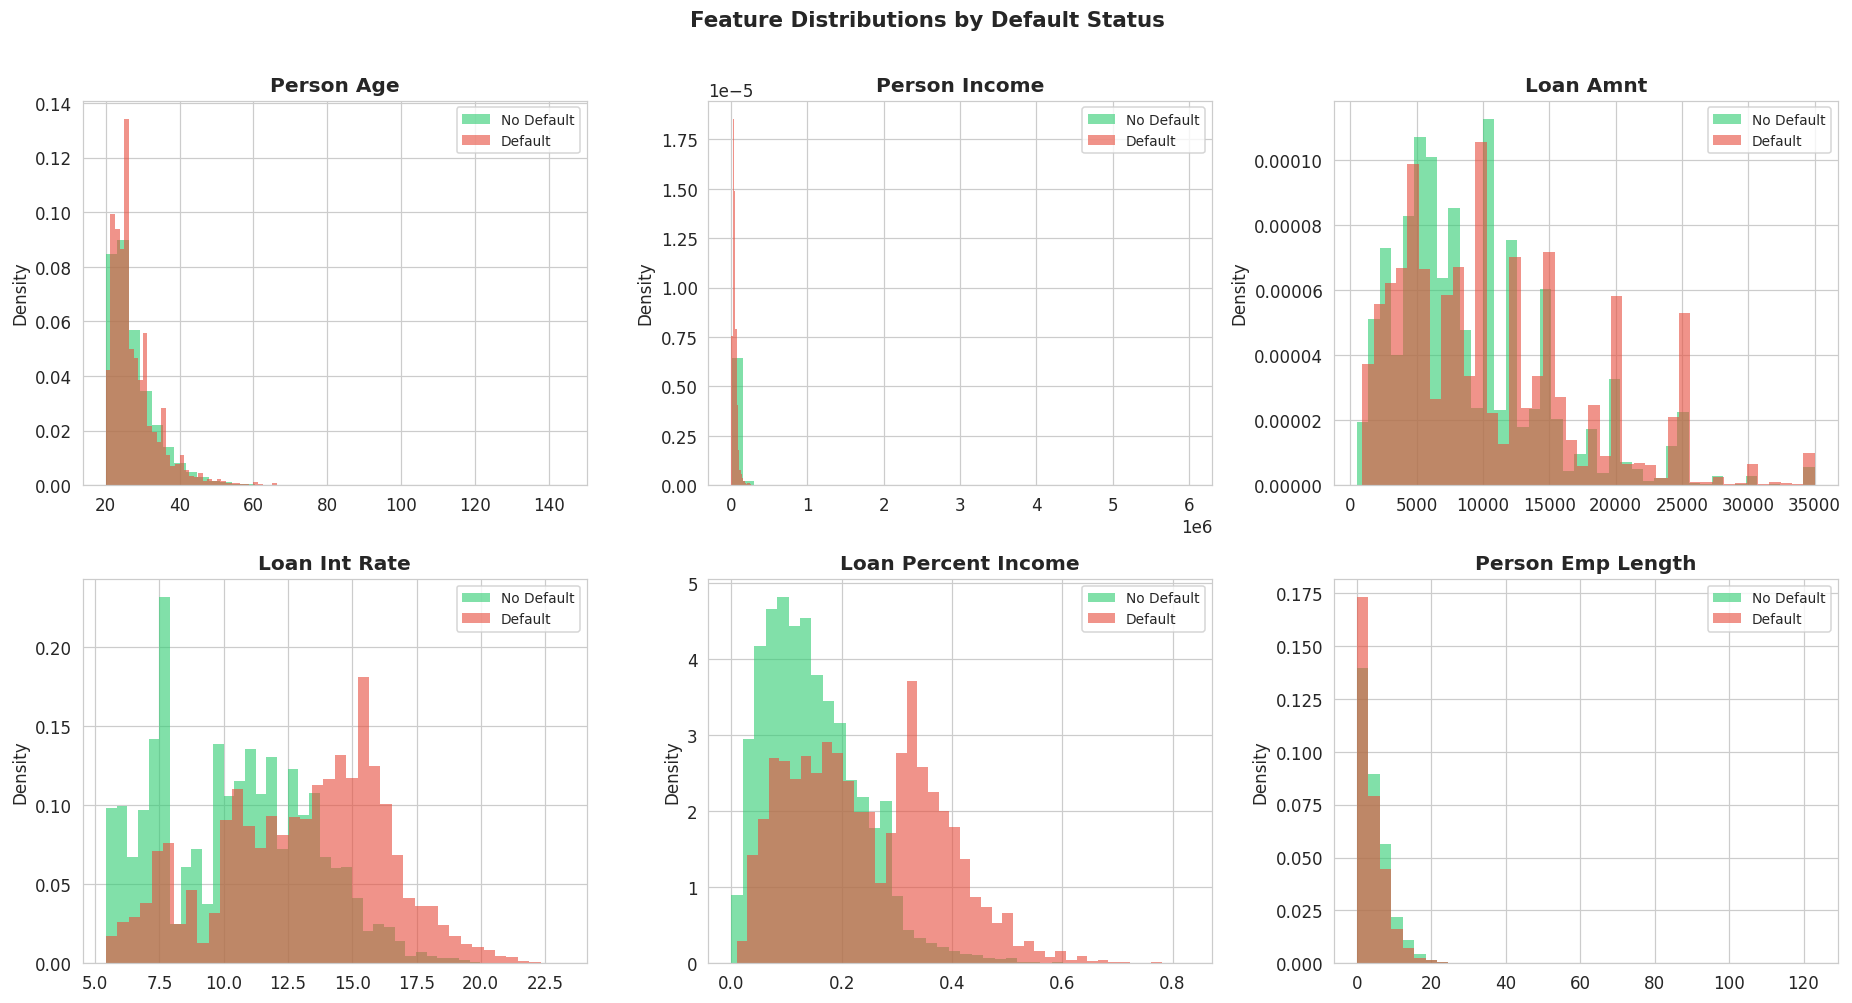

In [10]:
# ── Numeric feature distributions by loan_status ──────────────────────────────
num_cols = ['person_age', 'person_income', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'person_emp_length']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for status, color, label in [(0, COLORS['success'], 'No Default'),
                                  (1, COLORS['danger'],  'Default')]:
        axes[i].hist(df[df['loan_status'] == status][col].dropna(),
                     bins=40, alpha=0.6, color=color, label=label,
                     density=True, edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Default Status',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

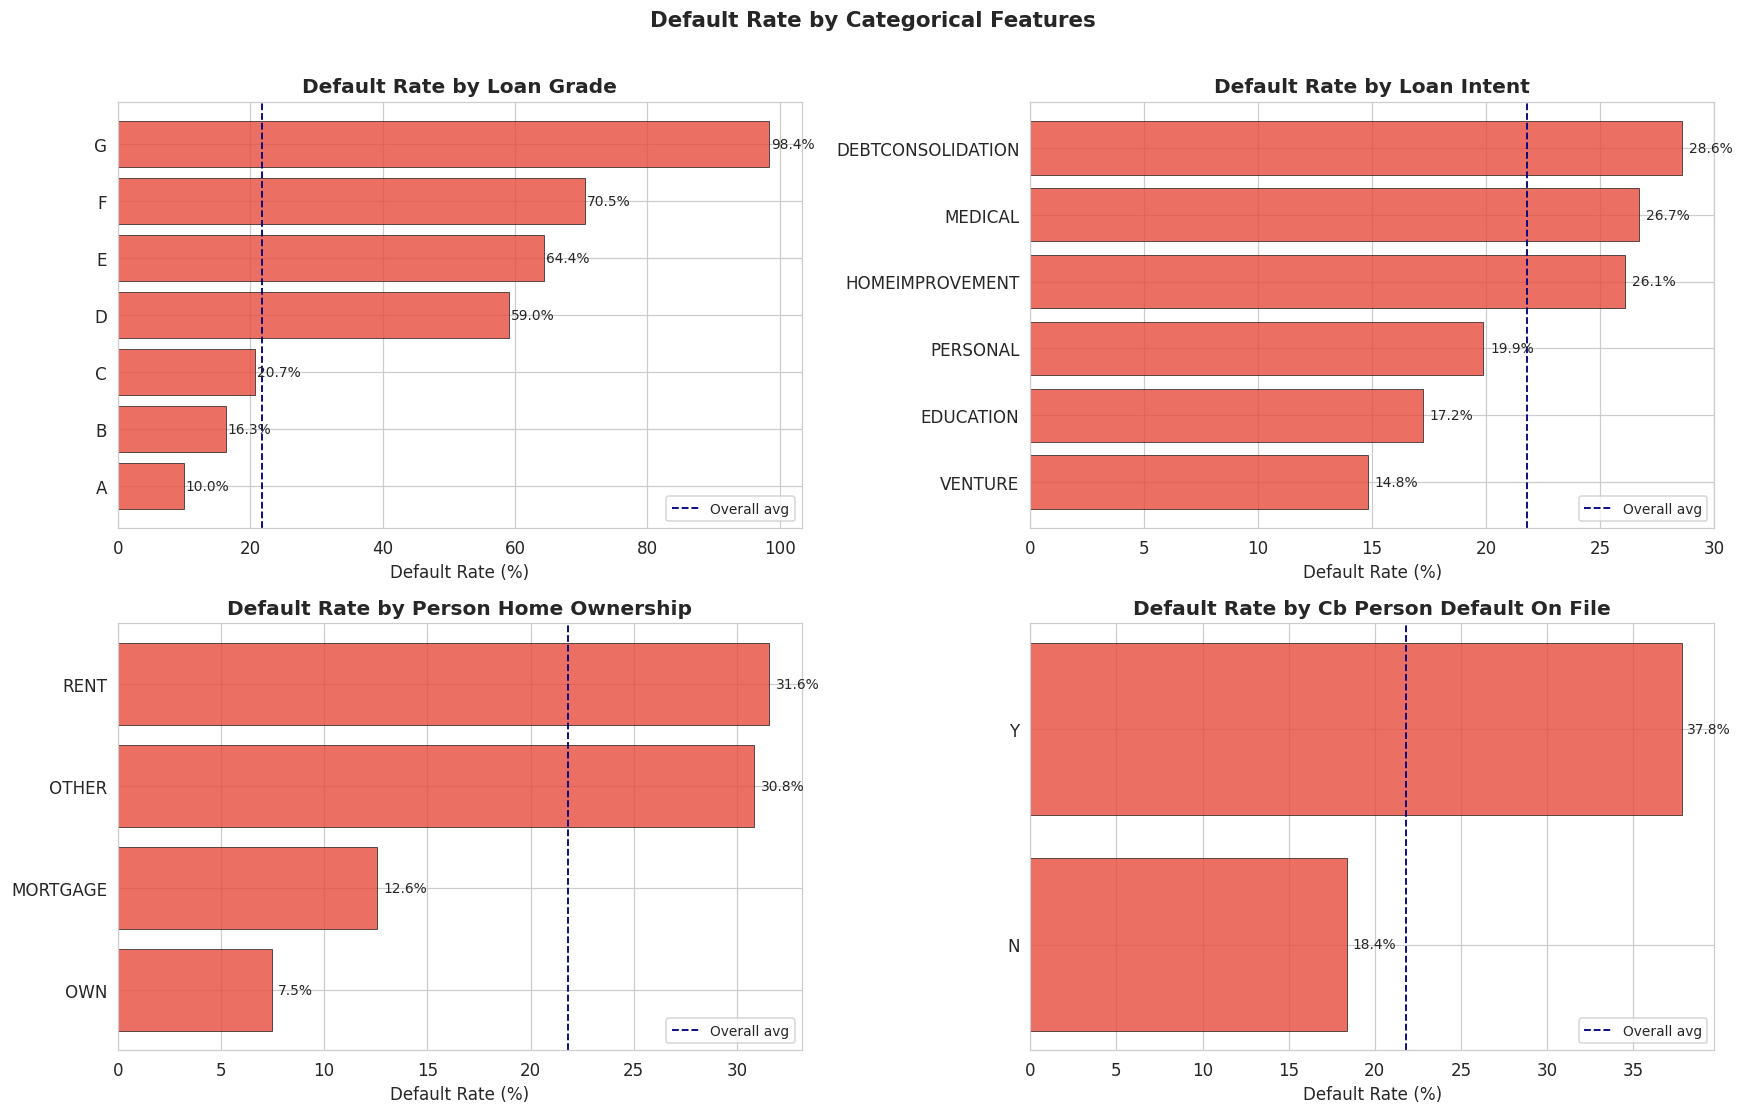

In [11]:
# ── Default rate by categorical features ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

cat_features = ['loan_grade', 'loan_intent', 'person_home_ownership', 'cb_person_default_on_file']

for i, col in enumerate(cat_features):
    rate = df.groupby(col)['loan_status'].mean().sort_values(ascending=True) * 100
    bars = axes[i].barh(rate.index, rate.values, color=COLORS['danger'],
                         alpha=0.8, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, rate.values):
        axes[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)
    axes[i].set_title(f'Default Rate by {col.replace("_"," ").title()}',
                       fontweight='bold')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].axvline(df['loan_status'].mean()*100, color='navy',
                    linestyle='--', linewidth=1.2, label='Overall avg')
    axes[i].legend(fontsize=9)

plt.suptitle('Default Rate by Categorical Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

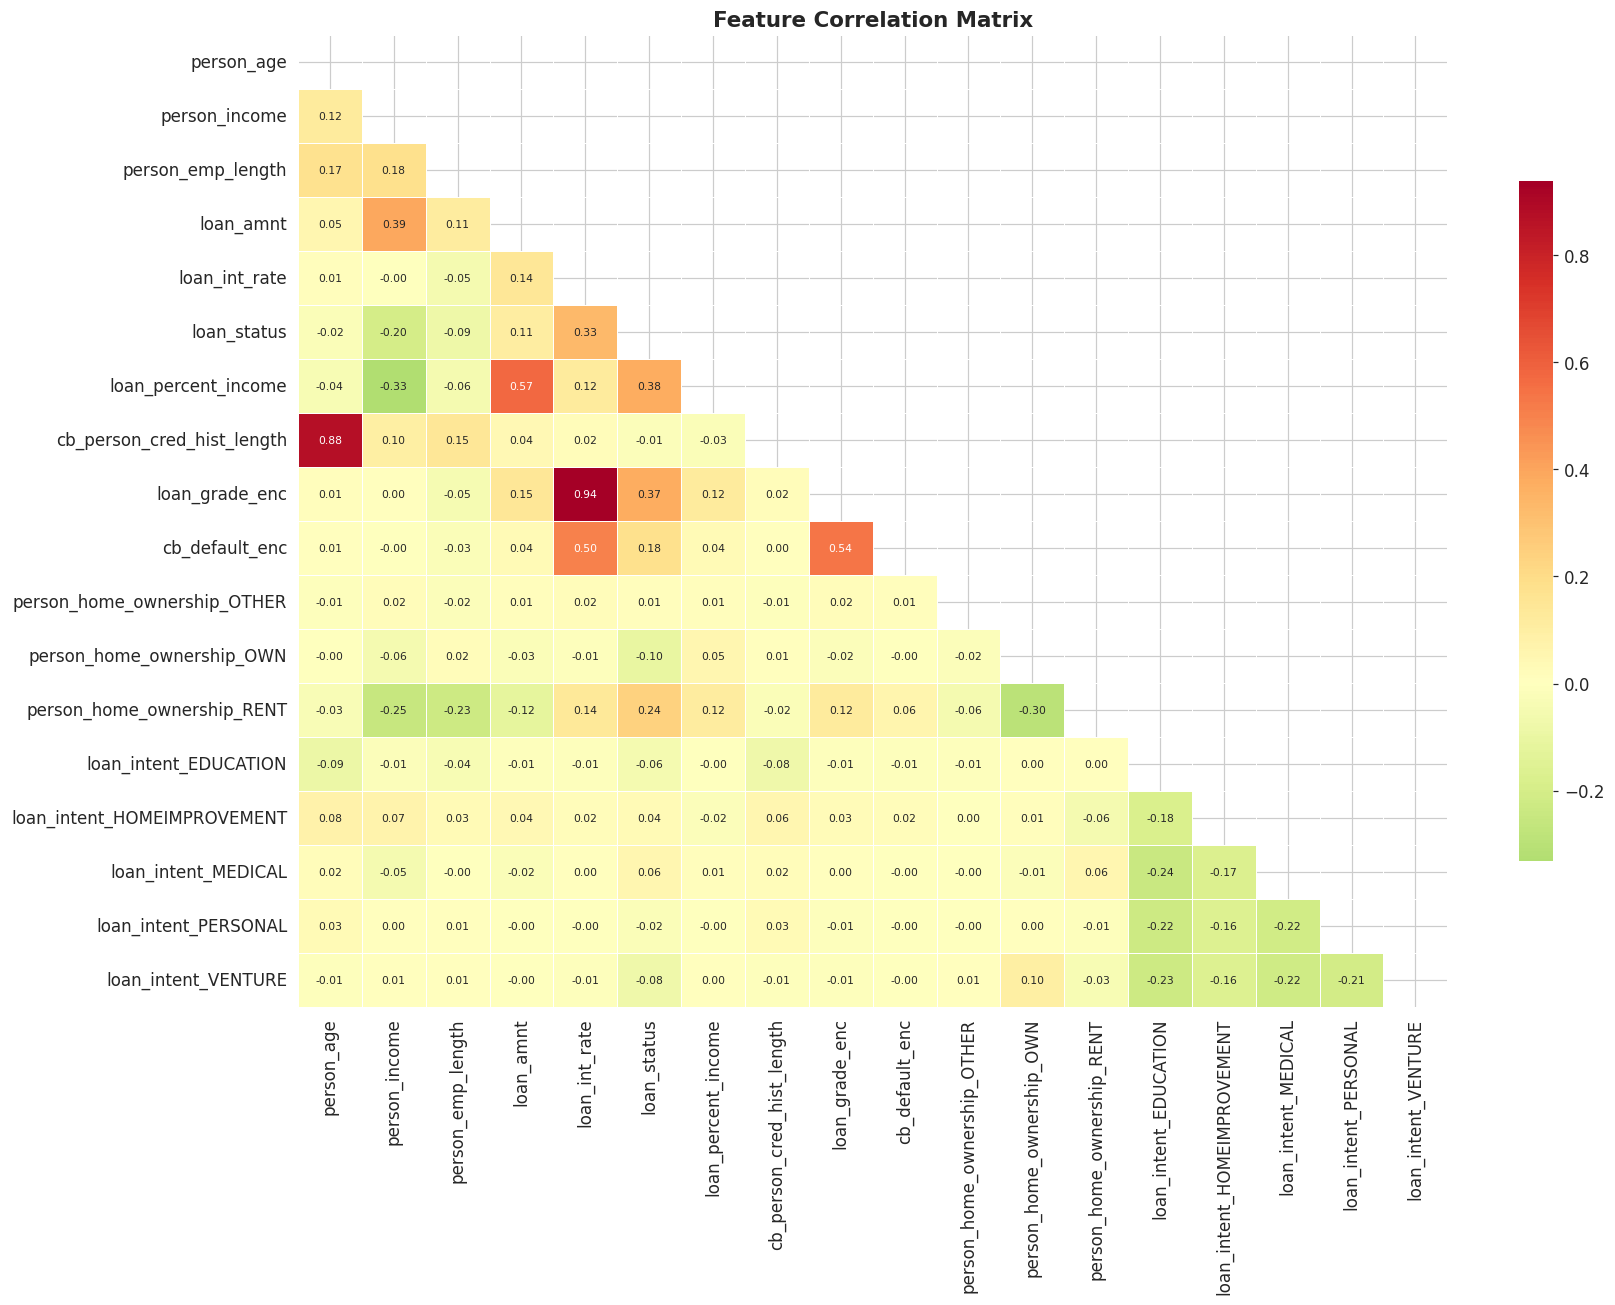

In [12]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
numeric_df = df_clean.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, cmap='RdYlGn_r',
            center=0, annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, square=False, cbar_kws={'shrink': 0.7})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 6: Feature Engineering

In [13]:
df_feat = df_clean.copy()

# ── Ratio features ────────────────────────────────────────────────────────────
# Monthly loan repayment burden (loan amount / annual income)
df_feat['loan_to_income']       = df_feat['loan_amnt'] / (df_feat['person_income'] + 1)

# Interest burden: annual interest amount / income
df_feat['interest_burden']      = (df_feat['loan_amnt'] * df_feat['loan_int_rate'] / 100) / \
                                   (df_feat['person_income'] + 1)

# Credit history per age: ratio of credit history length to person's age
df_feat['credit_to_age']        = df_feat['cb_person_cred_hist_length'] / (df_feat['person_age'] + 1)

# Loan amount relative to average for the grade (log ratio)
grade_avg = df_feat.groupby('loan_grade_enc')['loan_amnt'].transform('mean')
df_feat['loan_amnt_vs_grade']   = np.log1p(df_feat['loan_amnt']) - np.log1p(grade_avg)

# Log-transform skewed features
df_feat['log_income']   = np.log1p(df_feat['person_income'])
df_feat['log_loan_amnt']= np.log1p(df_feat['loan_amnt'])

print(' Feature engineering complete!')
print(f'   New shape: {df_feat.shape}')

 Feature engineering complete!
   New shape: (32541, 24)


##  Step 7: Train / Test Split & Class Imbalance (SMOTE)

In [14]:
# ── Define features and target ────────────────────────────────────────────────
TARGET = 'loan_status'
DROP_COLS = [TARGET]

X = df_feat.drop(columns=DROP_COLS)
y = df_feat[TARGET]

FEATURE_NAMES = list(X.columns)

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')

# ── 80/20 stratified split ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\nTrain size : {X_train.shape[0]:,} | Default rate: {y_train.mean()*100:.2f}%')
print(f'Test size  : {X_test.shape[0]:,}  | Default rate: {y_test.mean()*100:.2f}%')

Features : 23
Samples  : 32,541

Train size : 26,032 | Default rate: 21.83%
Test size  : 6,509  | Default rate: 21.83%


In [15]:
# ── Scale features (for Logistic Regression) ──────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── SMOTE oversampling on training set only ────────────────────────────────────
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(' SMOTE applied!')
print(f'   Before SMOTE: {dict(pd.Series(y_train).value_counts().sort_index())}')
print(f'   After  SMOTE: {dict(pd.Series(y_train_res).value_counts().sort_index())}')

 SMOTE applied!
   Before SMOTE: {0: np.int64(20348), 1: np.int64(5684)}
   After  SMOTE: {0: np.int64(20348), 1: np.int64(20348)}


##  Step 8: Model 1 — Logistic Regression
A strong, interpretable linear baseline for binary classification.

In [16]:
print('Training Logistic Regression...')

lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_res, y_train_res)

# Predict probabilities and classes
lr_proba  = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_pred   = lr_model.predict(X_test_scaled)

lr_auc    = roc_auc_score(y_test, lr_proba)
lr_ap     = average_precision_score(y_test, lr_proba)

print(f'\n Logistic Regression trained!')
print(f'   ROC-AUC : {lr_auc:.4f}')
print(f'   Avg Precision: {lr_ap:.4f}')
print(f'\n   Classification Report (threshold=0.5):')
print(classification_report(y_test, lr_pred, target_names=['No Default', 'Default']))

Training Logistic Regression...

 Logistic Regression trained!
   ROC-AUC : 0.8811
   Avg Precision: 0.7341

   Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No Default       0.93      0.82      0.87      5088
     Default       0.55      0.80      0.65      1421

    accuracy                           0.81      6509
   macro avg       0.74      0.81      0.76      6509
weighted avg       0.85      0.81      0.82      6509



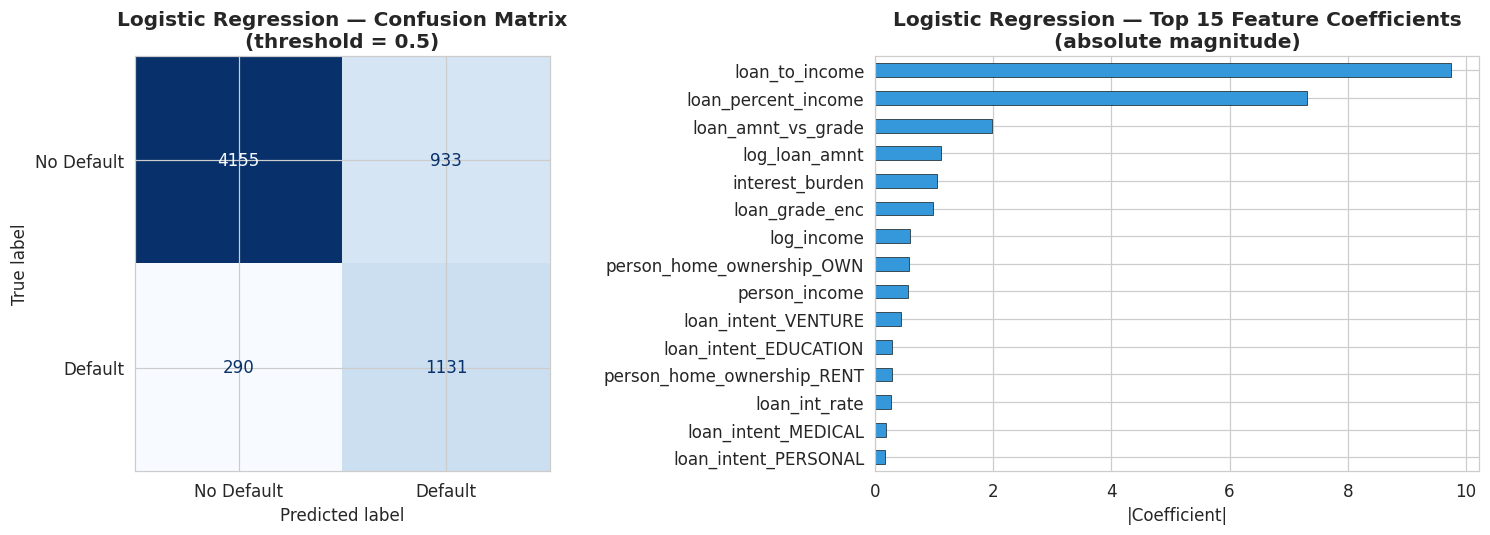

In [17]:
# ── Confusion Matrix — Logistic Regression ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['No Default', 'Default'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression — Confusion Matrix\n(threshold = 0.5)',
                   fontweight='bold')

# Coefficient importance
coef_df = pd.Series(np.abs(lr_model.coef_[0]), index=FEATURE_NAMES).nlargest(15)
coef_df.sort_values().plot(kind='barh', ax=axes[1], color=COLORS['info'],
                            edgecolor='black', linewidth=0.4)
axes[1].set_title('Logistic Regression — Top 15 Feature Coefficients\n(absolute magnitude)',
                   fontweight='bold')
axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.show()

##  Step 9: Model 2 — CatBoost
Gradient boosting that handles mixed-type features natively and delivers high accuracy.

In [18]:
print('Training CatBoost...')

# CatBoost can work on original (unscaled) data
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

# Apply SMOTE on raw data separately for CatBoost
smote_raw = SMOTE(random_state=RANDOM_STATE)
X_train_cb, y_train_cb = smote_raw.fit_resample(X_train_raw, y_train)

cb_model = CatBoostClassifier(
    iterations       = 500,
    learning_rate    = 0.05,
    depth            = 6,
    l2_leaf_reg      = 3,
    subsample        = 0.8,
    random_seed      = RANDOM_STATE,
    eval_metric      = 'AUC',
    early_stopping_rounds = 30,
    verbose          = 100
)

cb_model.fit(
    X_train_cb, y_train_cb,
    eval_set=(X_test_raw, y_test),
    use_best_model=True
)

cb_proba = cb_model.predict_proba(X_test_raw)[:, 1]
cb_pred  = cb_model.predict(X_test_raw)

cb_auc   = roc_auc_score(y_test, cb_proba)
cb_ap    = average_precision_score(y_test, cb_proba)

print(f'\n CatBoost trained!')
print(f'   ROC-AUC : {cb_auc:.4f}')
print(f'   Avg Precision: {cb_ap:.4f}')
print(f'\n   Classification Report (threshold=0.5):')
print(classification_report(y_test, cb_pred, target_names=['No Default', 'Default']))

Training CatBoost...
0:	test: 0.8588680	best: 0.8588680 (0)	total: 109ms	remaining: 54.6s
100:	test: 0.9165147	best: 0.9165147 (100)	total: 4.4s	remaining: 17.4s
200:	test: 0.9225771	best: 0.9225771 (200)	total: 7.61s	remaining: 11.3s
300:	test: 0.9276582	best: 0.9276803 (298)	total: 9.68s	remaining: 6.4s
400:	test: 0.9310941	best: 0.9310941 (400)	total: 11.2s	remaining: 2.75s
499:	test: 0.9346098	best: 0.9346098 (499)	total: 12.6s	remaining: 0us

bestTest = 0.9346098394
bestIteration = 499


 CatBoost trained!
   ROC-AUC : 0.9346
   Avg Precision: 0.8844

   Classification Report (threshold=0.5):
              precision    recall  f1-score   support

  No Default       0.93      0.98      0.96      5088
     Default       0.93      0.73      0.82      1421

    accuracy                           0.93      6509
   macro avg       0.93      0.86      0.89      6509
weighted avg       0.93      0.93      0.92      6509



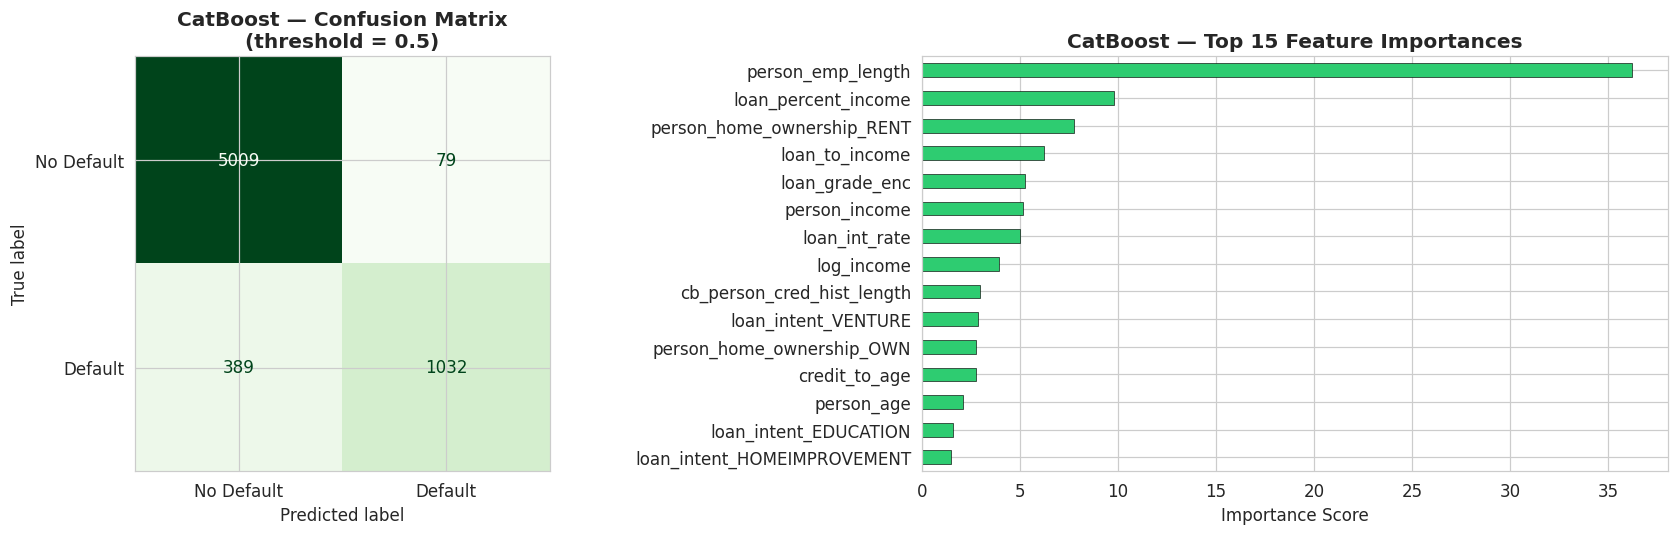

In [19]:
# ── Confusion Matrix + Feature Importance — CatBoost ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, cb_pred,
    display_labels=['No Default', 'Default'],
    cmap='Greens', ax=axes[0], colorbar=False
)
axes[0].set_title('CatBoost — Confusion Matrix\n(threshold = 0.5)', fontweight='bold')

fi_df = pd.Series(cb_model.get_feature_importance(),
                  index=FEATURE_NAMES).nlargest(15)
fi_df.sort_values().plot(kind='barh', ax=axes[1], color=COLORS['success'],
                          edgecolor='black', linewidth=0.4)
axes[1].set_title('CatBoost — Top 15 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

##  Step 10: ROC-AUC & Precision-Recall Analysis

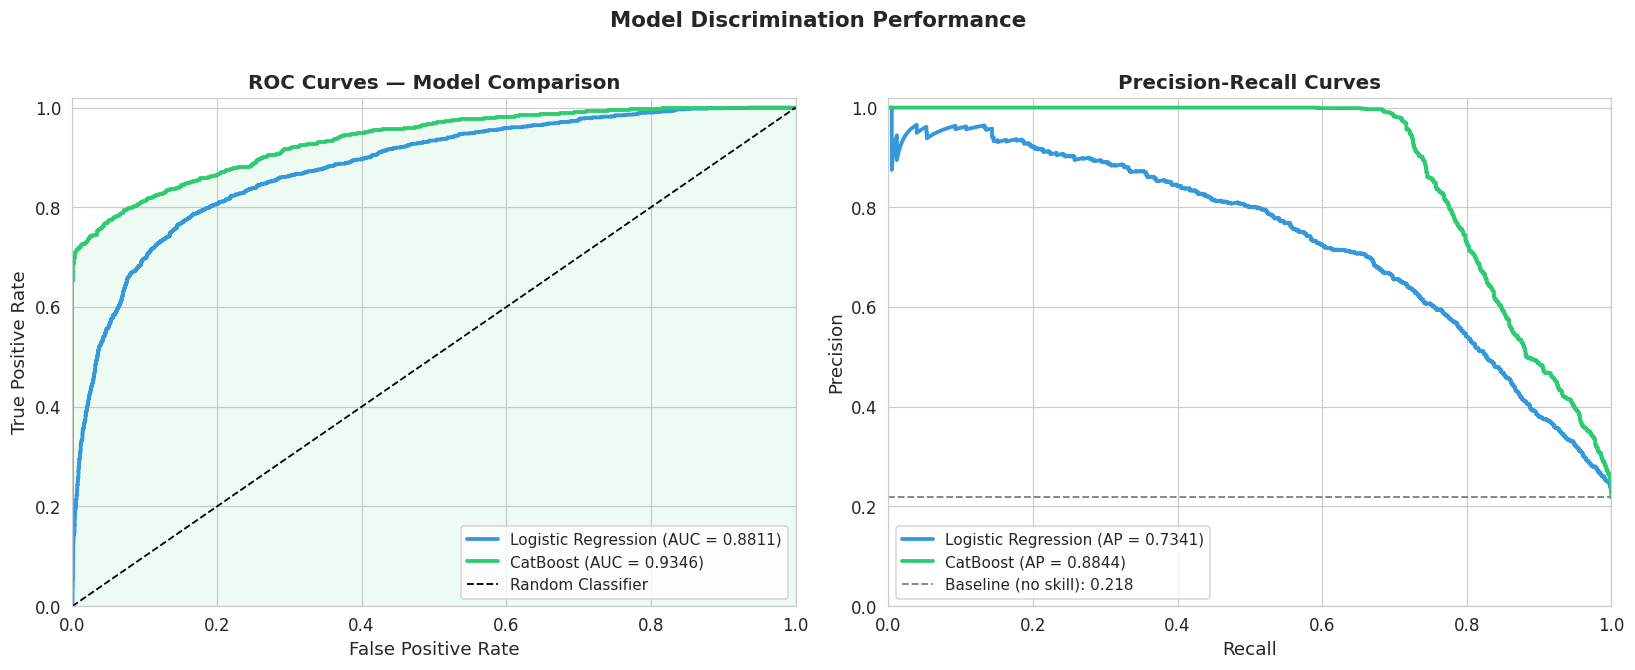

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── ROC Curves ────────────────────────────────────────────────────────────────
for name, proba, color in [
    ('Logistic Regression', lr_proba, COLORS['info']),
    ('CatBoost',            cb_proba, COLORS['success'])
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2.5, color=color,
                 label=f'{name} (AUC = {roc_auc_val:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
axes[0].fill_between(
    *roc_curve(y_test, cb_proba)[:2],
    alpha=0.08, color=COLORS['success']
)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# ── Precision-Recall Curves ───────────────────────────────────────────────────
baseline = y_test.mean()
for name, proba, color in [
    ('Logistic Regression', lr_proba, COLORS['info']),
    ('CatBoost',            cb_proba, COLORS['success'])
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, lw=2.5, color=color,
                 label=f'{name} (AP = {ap:.4f})')

axes[1].axhline(baseline, color='gray', linestyle='--', lw=1.2,
                label=f'Baseline (no skill): {baseline:.3f}')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.suptitle('Model Discrimination Performance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##  Step 11: Business Cost-Benefit Framework

In credit risk, two types of errors have very different business costs:

| Error Type | Prediction | Reality | Business Impact |
|------------|-----------|---------|------------------|
| **False Negative (FN)** | No Default | Actually Defaults | Bank loses loan principal + interest → **High Cost** |
| **False Positive (FP)** | Default | Actually Safe | Good customer rejected → Lost interest revenue → **Moderate Cost** |
| **True Positive (TP)** | Default | Actually Defaults | Risk avoided → **Benefit** |
| **True Negative (TN)** | No Default | Actually Safe | Profitable loan granted → **Benefit** |

We define costs per prediction as fractions of average loan amount.

In [21]:
# ── Business Cost Parameters ──────────────────────────────────────────────────
# These values can be adjusted to reflect real business parameters

AVG_LOAN       = df_clean['loan_amnt'].mean()          # Average loan amount
AVG_INT_RATE   = df_clean['loan_int_rate'].mean() / 100
AVG_INTEREST   = AVG_LOAN * AVG_INT_RATE               # Expected interest earned

# Cost definitions:
#   FN cost: Bank loses ~60% of loan principal (recovery rate ~40%)
#   FP cost: Lost net profit = interest revenue on a good loan (opportunity cost)
#   TP benefit: Avoided loss = FN cost (correctly flagged default)
#   TN benefit: Earned interest on a correctly approved safe loan

COST_FN  =  AVG_LOAN * 0.60    # False Negative: lose 60% of loan
COST_FP  =  AVG_INTEREST       # False Positive: lose potential interest revenue
BENEFIT_TP = COST_FN           # True Positive: avoided a default loss
BENEFIT_TN = AVG_INTEREST      # True Negative: earned interest on safe loan

print('=== Business Cost Parameters ===')
print(f'  Average loan amount       : ${AVG_LOAN:>10,.2f}')
print(f'  Average interest rate     : {AVG_INT_RATE*100:.2f}%')
print(f'  Average interest earned   : ${AVG_INTEREST:>10,.2f}')
print()
print(f'   Cost of False Negative  : ${COST_FN:>10,.2f}  (missed default → lose 60% principal)')
print(f'   Cost of False Positive  : ${COST_FP:>10,.2f}  (rejected safe customer → lost revenue)')
print(f'   Benefit of True Positive: ${BENEFIT_TP:>10,.2f}  (correctly rejected defaulter)')
print(f'   Benefit of True Negative: ${BENEFIT_TN:>10,.2f}  (correctly approved safe customer)')

=== Business Cost Parameters ===
  Average loan amount       : $  9,586.13
  Average interest rate     : 11.01%
  Average interest earned   : $  1,055.83

   Cost of False Negative  : $  5,751.68  (missed default → lose 60% principal)
   Cost of False Positive  : $  1,055.83  (rejected safe customer → lost revenue)
   Benefit of True Positive: $  5,751.68  (correctly rejected defaulter)
   Benefit of True Negative: $  1,055.83  (correctly approved safe customer)


In [22]:
def compute_total_cost(y_true, y_proba, threshold,
                       cost_fn, cost_fp, benefit_tp, benefit_tn):
    """
    Compute the net business cost at a given probability threshold.
    Returns: (total_cost, tn, fp, fn, tp, net_value)
    """
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost  = (fn * cost_fn) + (fp * cost_fp)
    total_benefit = (tp * benefit_tp) + (tn * benefit_tn)
    net_value   = total_benefit - total_cost

    return total_cost, tn, fp, fn, tp, net_value


# ── Sweep thresholds from 0.01 to 0.99 ────────────────────────────────────────
thresholds = np.linspace(0.01, 0.99, 200)

results_lr = []
results_cb = []

for t in thresholds:
    c_lr, tn, fp, fn, tp, nv = compute_total_cost(
        y_test, lr_proba, t, COST_FN, COST_FP, BENEFIT_TP, BENEFIT_TN)
    results_lr.append({'threshold': t, 'total_cost': c_lr,
                        'net_value': nv, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp})

    c_cb, tn, fp, fn, tp, nv = compute_total_cost(
        y_test, cb_proba, t, COST_FN, COST_FP, BENEFIT_TP, BENEFIT_TN)
    results_cb.append({'threshold': t, 'total_cost': c_cb,
                        'net_value': nv, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp})

df_lr_costs = pd.DataFrame(results_lr)
df_cb_costs = pd.DataFrame(results_cb)

# ── Optimal thresholds ────────────────────────────────────────────────────────
opt_lr_cost = df_lr_costs.loc[df_lr_costs['total_cost'].idxmin()]
opt_cb_cost = df_cb_costs.loc[df_cb_costs['total_cost'].idxmin()]

opt_lr_nv   = df_lr_costs.loc[df_lr_costs['net_value'].idxmax()]
opt_cb_nv   = df_cb_costs.loc[df_cb_costs['net_value'].idxmax()]

print('=== Optimal Thresholds (Minimum Cost) ===')
print(f'  Logistic Regression : threshold = {opt_lr_cost["threshold"]:.3f}  | '
      f'Total Cost = ${opt_lr_cost["total_cost"]:,.0f}')
print(f'  CatBoost            : threshold = {opt_cb_cost["threshold"]:.3f}  | '
      f'Total Cost = ${opt_cb_cost["total_cost"]:,.0f}')

print('\n=== Optimal Thresholds (Maximum Net Value) ===')
print(f'  Logistic Regression : threshold = {opt_lr_nv["threshold"]:.3f}  | '
      f'Net Value = ${opt_lr_nv["net_value"]:,.0f}')
print(f'  CatBoost            : threshold = {opt_cb_nv["threshold"]:.3f}  | '
      f'Net Value = ${opt_cb_nv["net_value"]:,.0f}')

=== Optimal Thresholds (Minimum Cost) ===
  Logistic Regression : threshold = 0.448  | Total Cost = $2,635,122
  CatBoost            : threshold = 0.217  | Total Cost = $2,055,692

=== Optimal Thresholds (Maximum Net Value) ===
  Logistic Regression : threshold = 0.448  | Net Value = $8,274,961
  CatBoost            : threshold = 0.217  | Net Value = $9,433,821


##  Step 12: Threshold Optimization Visualizations

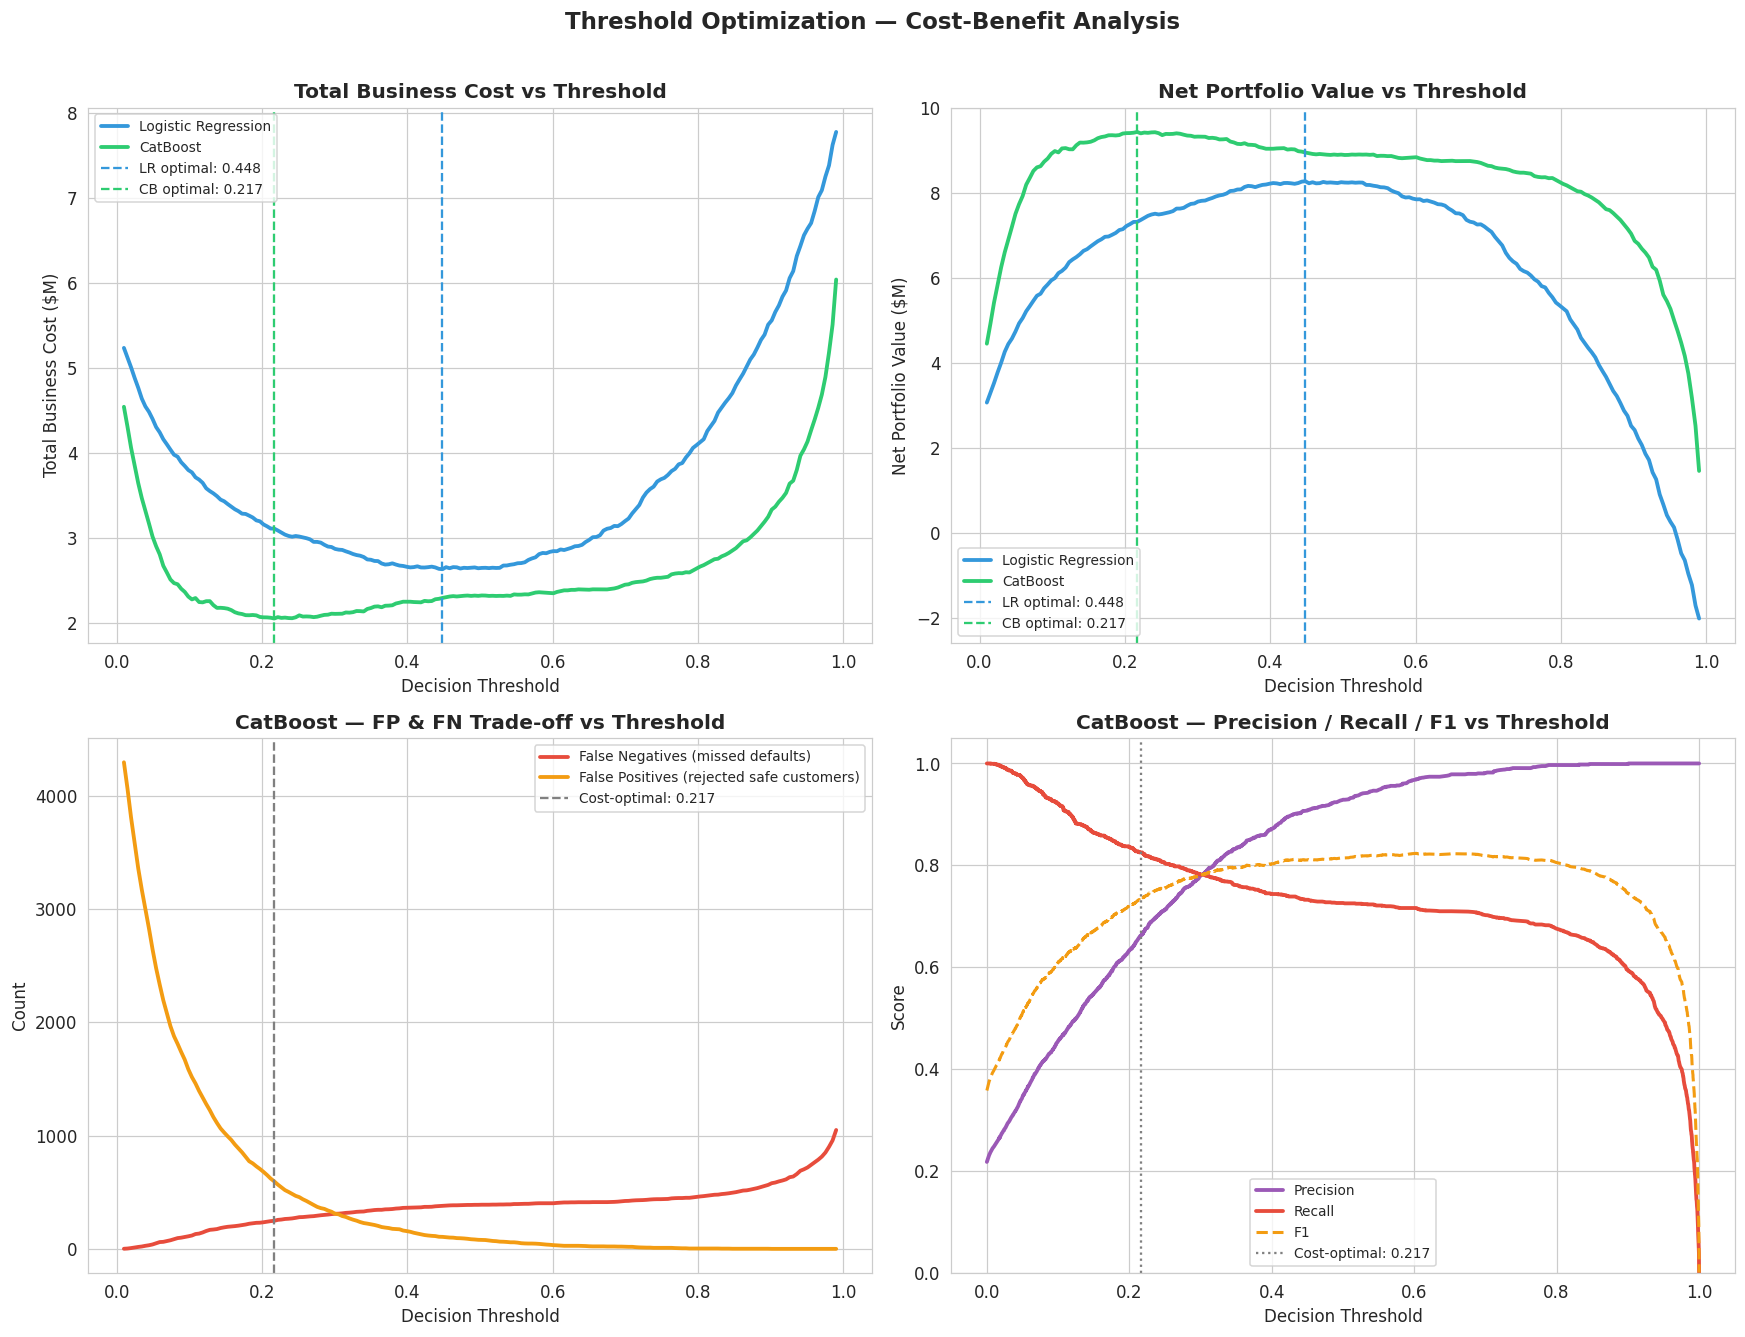

In [23]:
# ── Total Cost vs Threshold ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Total cost curve
axes[0, 0].plot(df_lr_costs['threshold'], df_lr_costs['total_cost'] / 1e6,
                lw=2.5, color=COLORS['info'], label='Logistic Regression')
axes[0, 0].plot(df_cb_costs['threshold'], df_cb_costs['total_cost'] / 1e6,
                lw=2.5, color=COLORS['success'], label='CatBoost')
axes[0, 0].axvline(opt_lr_cost['threshold'], color=COLORS['info'],
                    linestyle='--', lw=1.5,
                    label=f'LR optimal: {opt_lr_cost["threshold"]:.3f}')
axes[0, 0].axvline(opt_cb_cost['threshold'], color=COLORS['success'],
                    linestyle='--', lw=1.5,
                    label=f'CB optimal: {opt_cb_cost["threshold"]:.3f}')
axes[0, 0].set_xlabel('Decision Threshold')
axes[0, 0].set_ylabel('Total Business Cost ($M)')
axes[0, 0].set_title('Total Business Cost vs Threshold', fontweight='bold')
axes[0, 0].legend(fontsize=9)

# Plot 2: Net portfolio value curve
axes[0, 1].plot(df_lr_costs['threshold'], df_lr_costs['net_value'] / 1e6,
                lw=2.5, color=COLORS['info'], label='Logistic Regression')
axes[0, 1].plot(df_cb_costs['threshold'], df_cb_costs['net_value'] / 1e6,
                lw=2.5, color=COLORS['success'], label='CatBoost')
axes[0, 1].axvline(opt_lr_nv['threshold'], color=COLORS['info'],
                    linestyle='--', lw=1.5,
                    label=f'LR optimal: {opt_lr_nv["threshold"]:.3f}')
axes[0, 1].axvline(opt_cb_nv['threshold'], color=COLORS['success'],
                    linestyle='--', lw=1.5,
                    label=f'CB optimal: {opt_cb_nv["threshold"]:.3f}')
axes[0, 1].set_xlabel('Decision Threshold')
axes[0, 1].set_ylabel('Net Portfolio Value ($M)')
axes[0, 1].set_title('Net Portfolio Value vs Threshold', fontweight='bold')
axes[0, 1].legend(fontsize=9)

# Plot 3: FP & FN counts vs threshold (CatBoost)
axes[1, 0].plot(df_cb_costs['threshold'], df_cb_costs['fn'],
                lw=2.5, color=COLORS['danger'], label='False Negatives (missed defaults)')
axes[1, 0].plot(df_cb_costs['threshold'], df_cb_costs['fp'],
                lw=2.5, color=COLORS['warning'], label='False Positives (rejected safe customers)')
axes[1, 0].axvline(opt_cb_cost['threshold'], color='gray', linestyle='--', lw=1.5,
                    label=f'Cost-optimal: {opt_cb_cost["threshold"]:.3f}')
axes[1, 0].set_xlabel('Decision Threshold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('CatBoost — FP & FN Trade-off vs Threshold', fontweight='bold')
axes[1, 0].legend(fontsize=9)

# Plot 4: Precision, Recall vs Threshold (CatBoost)
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, cb_proba)
axes[1, 1].plot(thresh_arr, prec_arr[:-1], lw=2.5, color=COLORS['purple'], label='Precision')
axes[1, 1].plot(thresh_arr, rec_arr[:-1],  lw=2.5, color=COLORS['danger'],  label='Recall')
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
axes[1, 1].plot(thresh_arr, f1_arr, lw=2, color=COLORS['warning'], linestyle='--', label='F1')
axes[1, 1].axvline(opt_cb_cost['threshold'], color='gray', linestyle=':', lw=1.5,
                    label=f'Cost-optimal: {opt_cb_cost["threshold"]:.3f}')
axes[1, 1].set_xlabel('Decision Threshold')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('CatBoost — Precision / Recall / F1 vs Threshold', fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].set_ylim([0, 1.05])

plt.suptitle('Threshold Optimization — Cost-Benefit Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

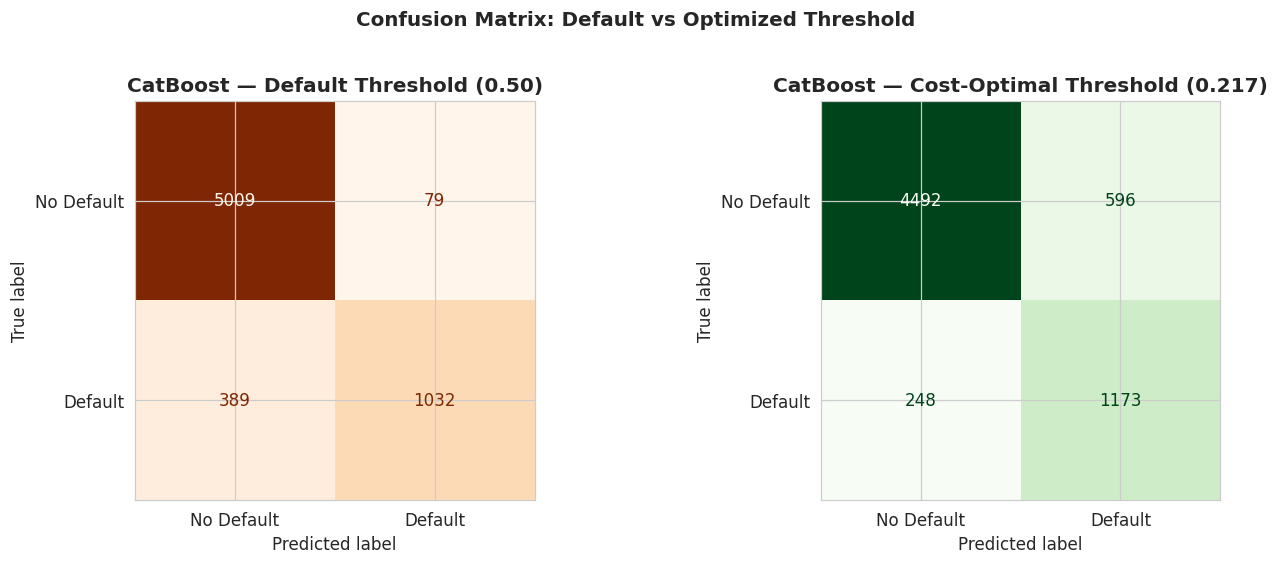


CatBoost at DEFAULT threshold (0.50):
              precision    recall  f1-score   support

  No Default       0.93      0.98      0.96      5088
     Default       0.93      0.73      0.82      1421

    accuracy                           0.93      6509
   macro avg       0.93      0.86      0.89      6509
weighted avg       0.93      0.93      0.92      6509


CatBoost at OPTIMIZED threshold (0.217):
              precision    recall  f1-score   support

  No Default       0.95      0.88      0.91      5088
     Default       0.66      0.83      0.74      1421

    accuracy                           0.87      6509
   macro avg       0.81      0.85      0.82      6509
weighted avg       0.89      0.87      0.88      6509



In [24]:
# ── Confusion matrices at default (0.5) vs optimized threshold ────────────────
OPT_THRESH_CB = opt_cb_cost['threshold']

cb_pred_opt  = (cb_proba >= OPT_THRESH_CB).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, cb_pred,
    display_labels=['No Default', 'Default'],
    cmap='Oranges', ax=axes[0], colorbar=False
)
axes[0].set_title('CatBoost — Default Threshold (0.50)', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, cb_pred_opt,
    display_labels=['No Default', 'Default'],
    cmap='Greens', ax=axes[1], colorbar=False
)
axes[1].set_title(f'CatBoost — Cost-Optimal Threshold ({OPT_THRESH_CB:.3f})', fontweight='bold')

plt.suptitle('Confusion Matrix: Default vs Optimized Threshold', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nCatBoost at DEFAULT threshold (0.50):')
print(classification_report(y_test, cb_pred, target_names=['No Default', 'Default']))
print(f'\nCatBoost at OPTIMIZED threshold ({OPT_THRESH_CB:.3f}):')
print(classification_report(y_test, cb_pred_opt, target_names=['No Default', 'Default']))

##  Step 13: Final Model Comparison & Business Impact Summary

In [25]:
# ── Compute metrics for all configurations ────────────────────────────────────
def get_metrics(y_true, y_proba, threshold, cost_fn, cost_fp, benefit_tp, benefit_tn):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost    = fn * cost_fn + fp * cost_fp
    total_benefit = tp * benefit_tp + tn * benefit_tn
    net_value     = total_benefit - total_cost
    auc_score     = roc_auc_score(y_true, y_proba)
    ap_score      = average_precision_score(y_true, y_proba)
    from sklearn.metrics import f1_score, precision_score, recall_score
    return {
        'Threshold'    : round(threshold, 3),
        'ROC-AUC'      : round(auc_score, 4),
        'Avg Precision': round(ap_score, 4),
        'Precision'    : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'       : round(recall_score(y_true, y_pred), 4),
        'F1'           : round(2 * precision_score(y_true, y_pred, zero_division=0) *
                               recall_score(y_true, y_pred) /
                               (precision_score(y_true, y_pred, zero_division=0) +
                                recall_score(y_true, y_pred) + 1e-8), 4),
        'TP' : tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'Total Cost ($)' : round(total_cost, 0),
        'Net Value ($)'  : round(net_value, 0),
    }

rows = [
    ('LR — Default (0.50)',       lr_proba, 0.50),
    ('LR — Cost-Optimal',         lr_proba, opt_lr_cost['threshold']),
    ('CatBoost — Default (0.50)', cb_proba, 0.50),
    ('CatBoost — Cost-Optimal',   cb_proba, opt_cb_cost['threshold']),
]

summary_rows = []
for label, proba, thresh in rows:
    m = get_metrics(y_test, proba, thresh, COST_FN, COST_FP, BENEFIT_TP, BENEFIT_TN)
    m['Configuration'] = label
    summary_rows.append(m)

summary_df = pd.DataFrame(summary_rows).set_index('Configuration')

print('\n' + '='*90)
print('              FINAL MODEL COMPARISON SUMMARY')
print('='*90)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}' if abs(x) < 10 else f'{x:,.0f}')
display(summary_df)
print('='*90)


              FINAL MODEL COMPARISON SUMMARY


,Threshold,ROC-AUC,Avg Precision,Precision,Recall,F1,TP,FP,FN,TN,Total Cost ($),Net Value ($)
Configuration,,,,,,,,,,,,
LR — Default (0.50),0.5000,0.8811,0.7341,0.5480,0.7959,0.6491,1131,933,290,4155,"2,653,077","8,239,050"
LR — Cost-Optimal,0.4480,0.8811,0.7341,0.5100,0.8227,0.6297,1169,1123,252,3965,"2,635,122","8,274,961"
CatBoost — Default (0.50),0.5000,0.9346,0.8844,0.9289,0.7262,0.8152,1032,79,389,5009,"2,320,813","8,903,579"
CatBoost — Cost-Optimal,0.2170,0.9346,0.8844,0.6631,0.8255,0.7354,1173,596,248,4492,"2,055,692","9,433,821"


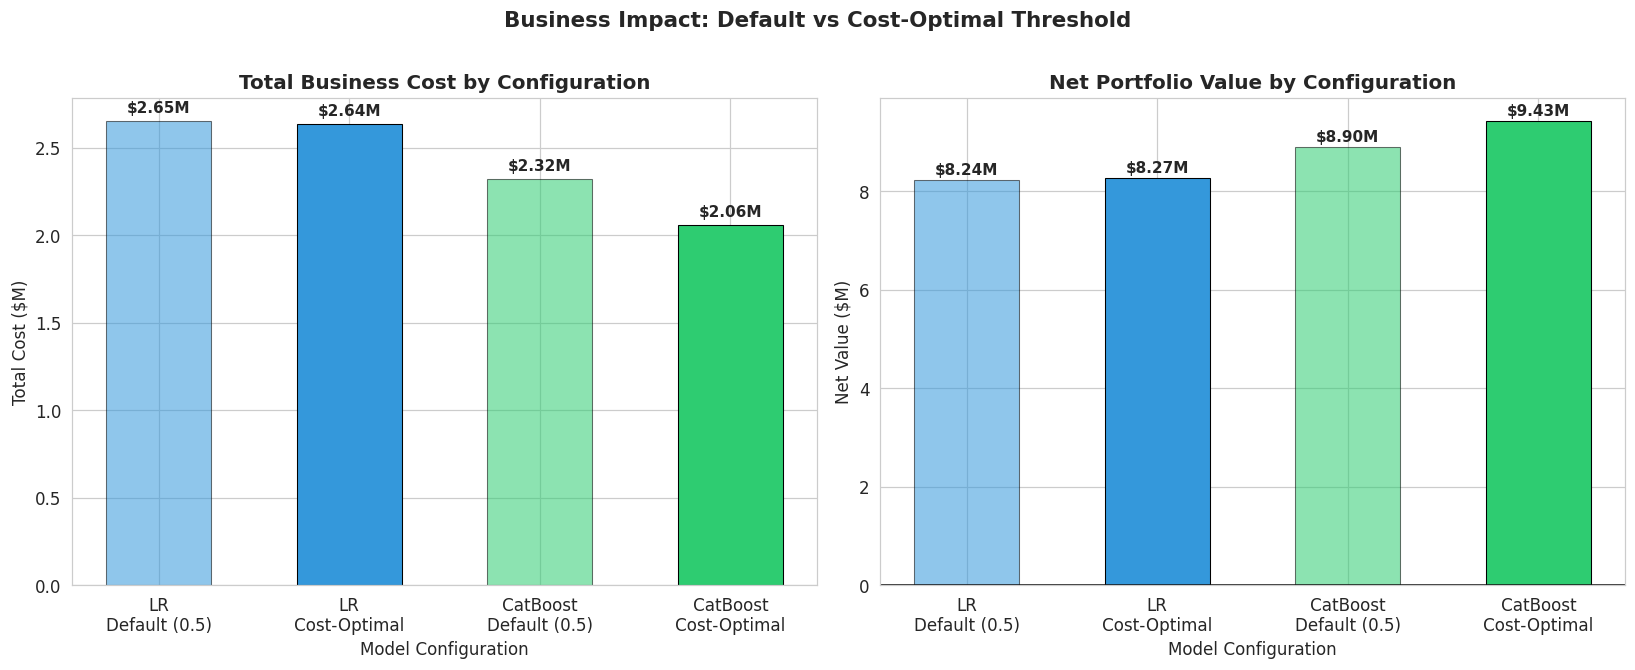

In [26]:
# ── Visual summary: Cost and Net Value comparison ─────────────────────────────
configs = ['LR\nDefault (0.5)', 'LR\nCost-Optimal',
           'CatBoost\nDefault (0.5)', 'CatBoost\nCost-Optimal']

total_costs = summary_df['Total Cost ($)'].values / 1e6
net_values  = summary_df['Net Value ($)'].values  / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

bar_colors = [COLORS['info'], COLORS['info'], COLORS['success'], COLORS['success']]
alphas     = [0.55, 1.0, 0.55, 1.0]

bars1 = axes[0].bar(configs, total_costs, color=bar_colors,
                     edgecolor='black', linewidth=0.7, width=0.55)
for bar, val, a in zip(bars1, total_costs, alphas):
    bar.set_alpha(a)
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'${val:.2f}M', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Total Business Cost by Configuration', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Total Cost ($M)')
axes[0].set_xlabel('Model Configuration')

bars2 = axes[1].bar(configs, net_values, color=bar_colors,
                     edgecolor='black', linewidth=0.7, width=0.55)
for bar, val, a in zip(bars2, net_values, alphas):
    bar.set_alpha(a)
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + (0.1 if val >= 0 else -0.3),
                 f'${val:.2f}M', ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Net Portfolio Value by Configuration', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Net Value ($M)')
axes[1].set_xlabel('Model Configuration')

plt.suptitle('Business Impact: Default vs Cost-Optimal Threshold',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

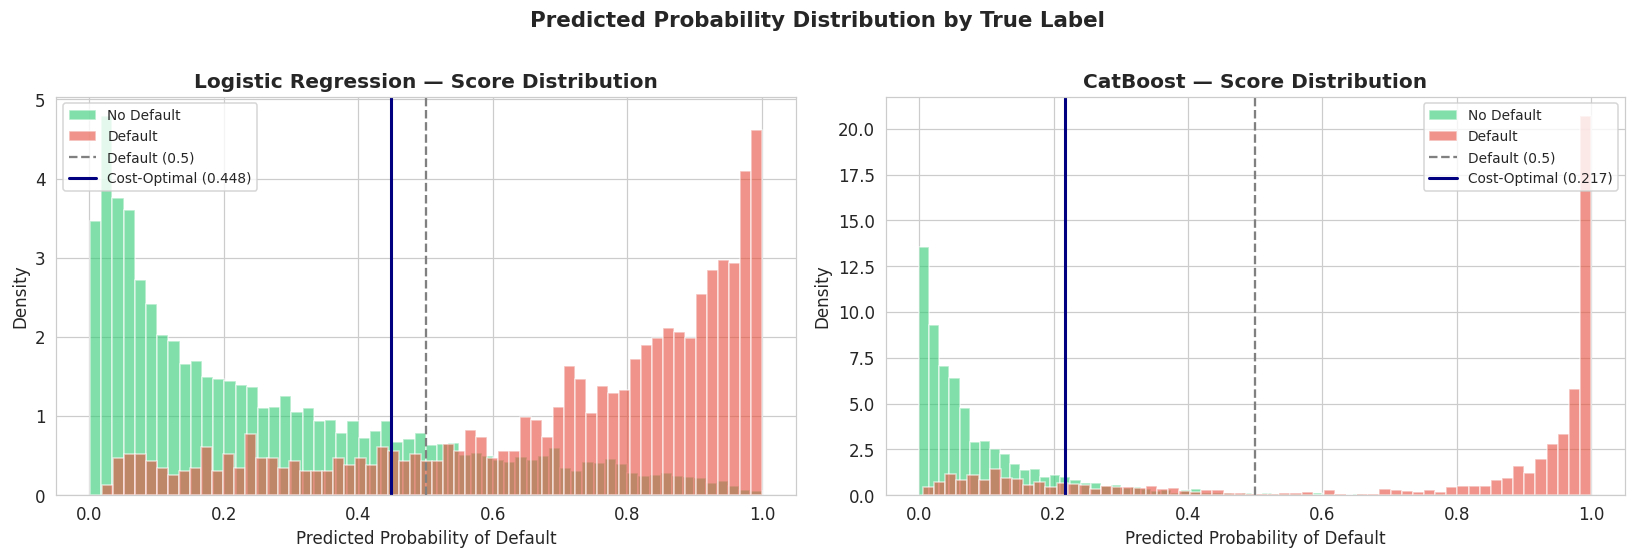

In [27]:
# ── SHAP-style: Logistic Regression probability calibration chart ─────────────
# Probability distribution by actual label
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, name, proba, opt_thresh in [
    (axes[0], 'Logistic Regression', lr_proba, opt_lr_cost['threshold']),
    (axes[1], 'CatBoost',            cb_proba, opt_cb_cost['threshold']),
]:
    ax.hist(proba[y_test == 0], bins=60, alpha=0.6, color=COLORS['success'],
            label='No Default', density=True)
    ax.hist(proba[y_test == 1], bins=60, alpha=0.6, color=COLORS['danger'],
            label='Default', density=True)
    ax.axvline(0.5, color='gray', linestyle='--', lw=1.5, label='Default (0.5)')
    ax.axvline(opt_thresh, color='navy', linestyle='-', lw=2,
               label=f'Cost-Optimal ({opt_thresh:.3f})')
    ax.set_xlabel('Predicted Probability of Default')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} — Score Distribution', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Predicted Probability Distribution by True Label',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##  Step 14: Key Insights & Recommendations

In [28]:
best_model_cost = 'CatBoost' if opt_cb_cost['total_cost'] < opt_lr_cost['total_cost'] else 'Logistic Regression'
best_model_nv   = 'CatBoost' if opt_cb_nv['net_value'] > opt_lr_nv['net_value'] else 'Logistic Regression'

cost_saving_vs_default = (
    get_metrics(y_test, cb_proba, 0.5, COST_FN, COST_FP, BENEFIT_TP, BENEFIT_TN)['Total Cost ($)'] -
    opt_cb_cost['total_cost']
)

print('\n' + '='*70)
print('         CREDIT RISK PREDICTION — FINAL SUMMARY')
print('='*70)
print(f'  Dataset         : Home Credit Default Risk ({len(df_clean):,} records)')
print(f'  Features Used   : {X.shape[1]}')
print(f'  Target          : loan_status  (0=No Default, 1=Default)')
print(f'  Default Rate    : {y.mean()*100:.2f}%  (class imbalance addressed via SMOTE)')
print('='*70)
print('\n  MODEL PERFORMANCE (ROC-AUC):')
print(f'    Logistic Regression : {lr_auc:.4f}')
print(f'    CatBoost            : {cb_auc:.4f}  ← Best')
print('\n  COST-OPTIMAL THRESHOLDS:')
print(f'    Logistic Regression : {opt_lr_cost["threshold"]:.3f}  (cost: ${opt_lr_cost["total_cost"]:,.0f})')
print(f'    CatBoost            : {opt_cb_cost["threshold"]:.3f}  (cost: ${opt_cb_cost["total_cost"]:,.0f})')
print(f'\n  COST SAVING vs DEFAULT THRESHOLD (CatBoost):')
print(f'    ${cost_saving_vs_default:,.0f} saved by using optimized threshold')
print('='*70)
print('\n  KEY INSIGHTS:')
print('  1. CatBoost significantly outperforms Logistic Regression on AUC')
print('  2. False Negatives (missed defaults) are far more costly than FP')
print('  3. Threshold optimization reduces total cost by lowering FN count')
print('  4. Loan grade, interest rate, and loan_percent_income are top predictors')
print('  5. SMOTE improved recall for the minority (default) class')
print('\n  RECOMMENDATIONS:')
print(f'  → Deploy CatBoost with threshold = {opt_cb_cost["threshold"]:.3f} for production')
print('  → Review cost parameters quarterly as recovery rates change')
print('  → Monitor score distributions for distribution drift over time')
print('='*70)


         CREDIT RISK PREDICTION — FINAL SUMMARY
  Dataset         : Home Credit Default Risk (32,541 records)
  Features Used   : 23
  Target          : loan_status  (0=No Default, 1=Default)
  Default Rate    : 21.83%  (class imbalance addressed via SMOTE)

  MODEL PERFORMANCE (ROC-AUC):
    Logistic Regression : 0.8811
    CatBoost            : 0.9346  ← Best

  COST-OPTIMAL THRESHOLDS:
    Logistic Regression : 0.448  (cost: $2,635,122)
    CatBoost            : 0.217  (cost: $2,055,692)

  COST SAVING vs DEFAULT THRESHOLD (CatBoost):
    $265,121 saved by using optimized threshold

  KEY INSIGHTS:
  1. CatBoost significantly outperforms Logistic Regression on AUC
  2. False Negatives (missed defaults) are far more costly than FP
  3. Threshold optimization reduces total cost by lowering FN count
  4. Loan grade, interest rate, and loan_percent_income are top predictors
  5. SMOTE improved recall for the minority (default) class

  RECOMMENDATIONS:
  → Deploy CatBoost with threshol